# TDA of digital images

## CoREMOF

In [1]:
from CoREMOF.structure import download_from_SI, information

You need to install CSD software with the license if you want to download all structures


In [ ]:
download_from_SI(output_folder='../datasets/CoREMOF2025DB')

In [2]:
data = information("CR-ASR", "2020[Cu][sql]2[ASR]1")
data

unit:
 {'LCD': 'Å', 'PLD': 'Å', 'LFPD': 'Å', 'Density': 'g/cm3', 'ASA': 'Å2', 'GSA': 'm2/g', 'VSA': 'm2/cm3', 'NASA': 'Å2', 'NGSA': 'm2/g', 'NVSA': 'm2/cm3', 'PV': 'Å3', 'GPV': 'cm3/g', 'NPV': 'Å3', 'NGPV': 'cm3/g', 'AtomicMass': 'amu', 'HeatCapacity': 'J/g/K', 'Stability_Thermal': '℃', 'Widom': 'mmol/g/Pa', 'GEMC': 'Molecules/Supercell'}


{'refcode': '10876_2020_1817_MOESM2_ESM_ASR_pacman',
 'name': 'nan',
 'mofid': {'v1': 'Nc1cnccc1c1ccncc1.[Cu] MOFid-v1.sql.cat1;10876_2020_1817_MOESM2_ESM_ASR_pacman',
  'v2': '[Cu1_Type-1].[N][C][=C][N][=C][C][=C][Ring1][=Branch1][C][=C][C][=N][C][=C][Ring1][=Branch1] MOFid-v2.sql.cat1;10876_2020_1817_MOESM2_ESM_ASR_pacman'},
 'LCD': 8.85794,
 'PLD': 5.7866,
 'LFPD': 8.85794,
 'Density': 0.578816,
 'ASA': 1360.43,
 'GSA': 5045.35,
 'VSA': 2920.33,
 'NASA': 0.0,
 'NGSA': 0.0,
 'NVSA': 0.0,
 'PV': 3519.94,
 'VF': 0.7556,
 'GPV': 1.30542,
 'NPV': 0.0,
 'NGPV': 0.0,
 'Dimension': 2,
 'Topology': {'SingleNode': 'sql',
  'AllNode': 'sql',
  'Catenation': 2,
  'Dimension': 2},
 'SpaceGroup': {'hall': '-P 2 2n', 'number': 58},
 'Metal': 'Cu',
 'hasOMS': 'Yes',
 'TypeOMS': 'Cu',
 'Charge': 'PACMAN-DDEC6',
 'AtomicMass': 9.020958222,
 'HeatCapacity': {'300K': 0.896209663,
  '350K': 1.020818056,
  '400K': 1.073200056},
 'NAtoms': 180,
 'Source': 'SI',
 'DOI': '10.1007/s10876-020-01817-4',
 'Year

Baseline TDA Pipeline for HeatCapacity Prediction

In [3]:
# Import necessary libraries
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from ripser import ripser
from persim import PersistenceImager
from pymatgen.core import Structure
import warnings
warnings.filterwarnings('ignore')

Data Collection from CoREMOF2025 CR-ASR Dataset

In [ ]:
# Get all ASR material IDs from downloaded CIF files
dataset_path = '../datasets/CoREMOF2025DB/CR'
asr_files = glob.glob(os.path.join(dataset_path, '*[ASR]*.cif'))
material_ids = [os.path.basename(f).replace('.cif', '') for f in asr_files]

print(f"Total materials in CR-ASR dataset: {len(material_ids)}")

# Collect data for materials with HeatCapacity information
mof_data = []
structures = []

for i, mat_id in enumerate(material_ids[:500]):  # Start with first 500 for baseline
    try:
        # Get metadata
        data = information("CR-ASR", mat_id)
        
        # Check if HeatCapacity data exists at 300K
        if 'HeatCapacity' in data and data['HeatCapacity'] and '300K' in data['HeatCapacity']:
            heat_cap = data['HeatCapacity']['300K']
            
            # Load the structure using pymatgen
            cif_path = os.path.join(dataset_path, f"{mat_id}.cif")
            structure = Structure.from_file(cif_path)
            
            mof_data.append({
                'material_id': mat_id,
                'heat_capacity': heat_cap,
                'n_atoms': len(structure),
                'density': data.get('Density', 0),
                'pld': data.get('PLD', 0),
                'lcd': data.get('LCD', 0)
            })
            structures.append(structure)
            
    except Exception as e:
        continue
    
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{min(500, len(material_ids))} materials, collected {len(mof_data)} with HeatCapacity data")

print(f"\nTotal MOFs with HeatCapacity data: {len(mof_data)}")
df = pd.DataFrame(mof_data)
print(f"Dataset shape: {df.shape}")
print(f"\nSample data:")
df.head()

In [6]:
df.to_csv('tmp.csv')

Convert MOF Structures to Point Clouds

In [5]:
def structure_to_point_cloud(structure, max_points=500):
    """
    Convert pymatgen Structure to point cloud.
    For large structures, subsample to max_points.
    """
    # Get fractional coordinates (normalized to unit cell)
    coords = structure.frac_coords
    
    # If structure has too many atoms, subsample
    if len(coords) > max_points:
        indices = np.random.choice(len(coords), max_points, replace=False)
        coords = coords[indices]
    
    return coords

# Convert all structures to point clouds
point_clouds = []
for structure in structures:
    pc = structure_to_point_cloud(structure)
    point_clouds.append(pc)

print(f"Created {len(point_clouds)} point clouds")
print(f"Example point cloud shape: {point_clouds[0].shape}")

Created 273 point clouds
Example point cloud shape: (166, 3)


Compute Persistent Homology and Extract TDA Features

In [6]:
def compute_persistence(point_cloud, maxdim=2):
    """
    Compute persistent homology using Vietoris-Rips filtration.
    Returns persistence diagrams for H0, H1, H2.
    """
    result = ripser(point_cloud, maxdim=maxdim)
    return result['dgms']

def extract_persistence_statistics(diagrams):
    """
    Extract statistical features from persistence diagrams.
    Features: birth, death, lifetime statistics for each homology dimension.
    """
    features = []
    
    for dim, dgm in enumerate(diagrams):
        if len(dgm) == 0:
            # No features in this dimension
            features.extend([0, 0, 0, 0, 0, 0, 0, 0, 0])
            continue
        
        births = dgm[:, 0]
        deaths = dgm[:, 1]
        lifetimes = deaths - births
        
        # Remove infinite persistence (connected components in H0)
        finite_mask = np.isfinite(lifetimes)
        if np.sum(finite_mask) == 0:
            features.extend([0, 0, 0, 0, 0, 0, 0, 0, 0])
            continue
            
        births_finite = births[finite_mask]
        deaths_finite = deaths[finite_mask]
        lifetimes_finite = lifetimes[finite_mask]
        
        # Statistical features
        features.extend([
            np.mean(births_finite),
            np.std(births_finite),
            np.max(births_finite),
            np.mean(deaths_finite),
            np.std(deaths_finite),
            np.max(deaths_finite),
            np.mean(lifetimes_finite),
            np.std(lifetimes_finite),
            np.max(lifetimes_finite),
        ])
    
    return np.array(features)

# Compute persistent homology for all point clouds
print("Computing persistent homology...")
all_diagrams = []
for i, pc in enumerate(point_clouds):
    diagrams = compute_persistence(pc, maxdim=2)
    all_diagrams.append(diagrams)
    
    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(point_clouds)} point clouds")

print("\nExtracting TDA features...")
tda_features = []
for diagrams in all_diagrams:
    features = extract_persistence_statistics(diagrams)
    tda_features.append(features)

tda_features = np.array(tda_features)
print(f"TDA feature matrix shape: {tda_features.shape}")
print(f"Features per structure: {tda_features.shape[1]}")

Computing persistent homology...
Processed 50/273 point clouds
Processed 100/273 point clouds
Processed 150/273 point clouds
Processed 200/273 point clouds
Processed 250/273 point clouds

Extracting TDA features...
TDA feature matrix shape: (273, 27)
Features per structure: 27


Train Ridge Regression Baseline Model

In [7]:
# Prepare data
X = tda_features
y = df['heat_capacity'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nHeatCapacity statistics:")
print(f"  Mean: {np.mean(y):.4f} J/g/K")
print(f"  Std:  {np.std(y):.4f} J/g/K")
print(f"  Min:  {np.min(y):.4f} J/g/K")
print(f"  Max:  {np.max(y):.4f} J/g/K")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Ridge Regression with cross-validation to find best alpha
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
cv_scores = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, 
                             scoring='neg_mean_absolute_error')
    cv_scores.append(-scores.mean())

best_alpha = alphas[np.argmin(cv_scores)]
print(f"\nBest alpha from CV: {best_alpha}")
print(f"Best CV MAE: {min(cv_scores):.4f} J/g/K")

# Train final model with best alpha
model = Ridge(alpha=best_alpha)
model.fit(X_train_scaled, y_train)

print("\nModel trained successfully!")

Feature matrix shape: (273, 27)
Target vector shape: (273,)

HeatCapacity statistics:
  Mean: 0.8110 J/g/K
  Std:  0.1018 J/g/K
  Min:  0.5277 J/g/K
  Max:  0.9963 J/g/K

Train set size: 218
Test set size: 55

Best alpha from CV: 10
Best CV MAE: 0.0776 J/g/K

Model trained successfully!


Model Evaluation and Results

In [8]:
# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("="*60)
print("BASELINE TDA PIPELINE RESULTS")
print("="*60)
print("\nTrain Set Performance:")
print(f"  MAE:  {train_mae:.4f} J/g/K")
print(f"  RMSE: {train_rmse:.4f} J/g/K")
print(f"  R²:   {train_r2:.4f}")

print("\nTest Set Performance:")
print(f"  MAE:  {test_mae:.4f} J/g/K")
print(f"  RMSE: {test_rmse:.4f} J/g/K")
print(f"  R²:   {test_r2:.4f}")
print("="*60)

BASELINE TDA PIPELINE RESULTS

Train Set Performance:
  MAE:  0.0720 J/g/K
  RMSE: 0.0874 J/g/K
  R²:   0.2282

Test Set Performance:
  MAE:  0.0886 J/g/K
  RMSE: 0.1075 J/g/K
  R²:   -0.1112


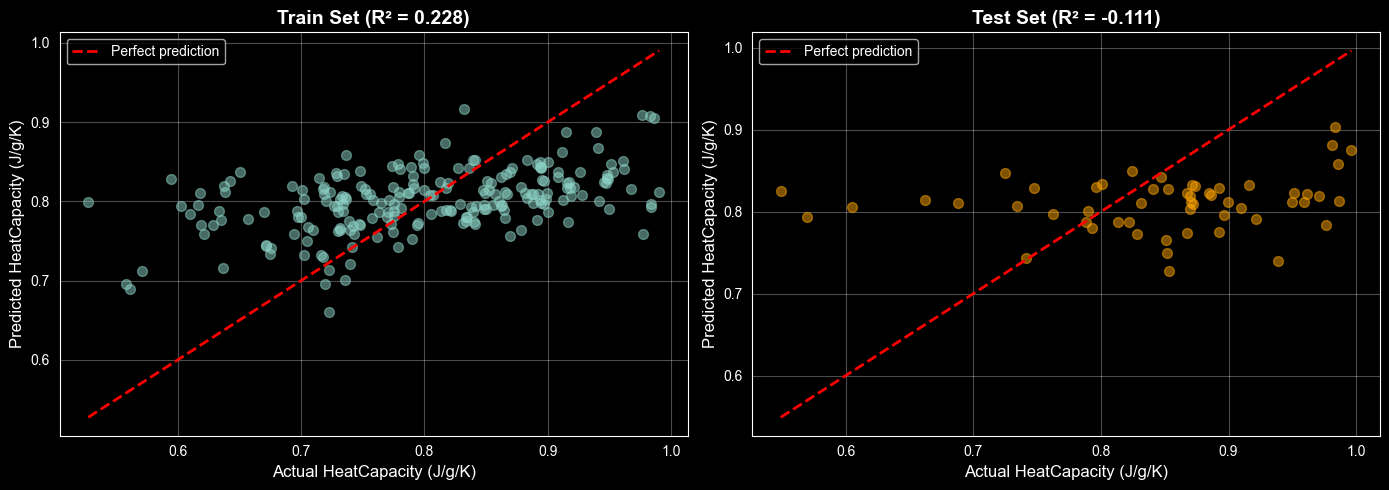

In [9]:
# Visualization: Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=50)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual HeatCapacity (J/g/K)', fontsize=12)
axes[0].set_ylabel('Predicted HeatCapacity (J/g/K)', fontsize=12)
axes[0].set_title(f'Train Set (R² = {train_r2:.3f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=50, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual HeatCapacity (J/g/K)', fontsize=12)
axes[1].set_ylabel('Predicted HeatCapacity (J/g/K)', fontsize=12)
axes[1].set_title(f'Test Set (R² = {test_r2:.3f})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

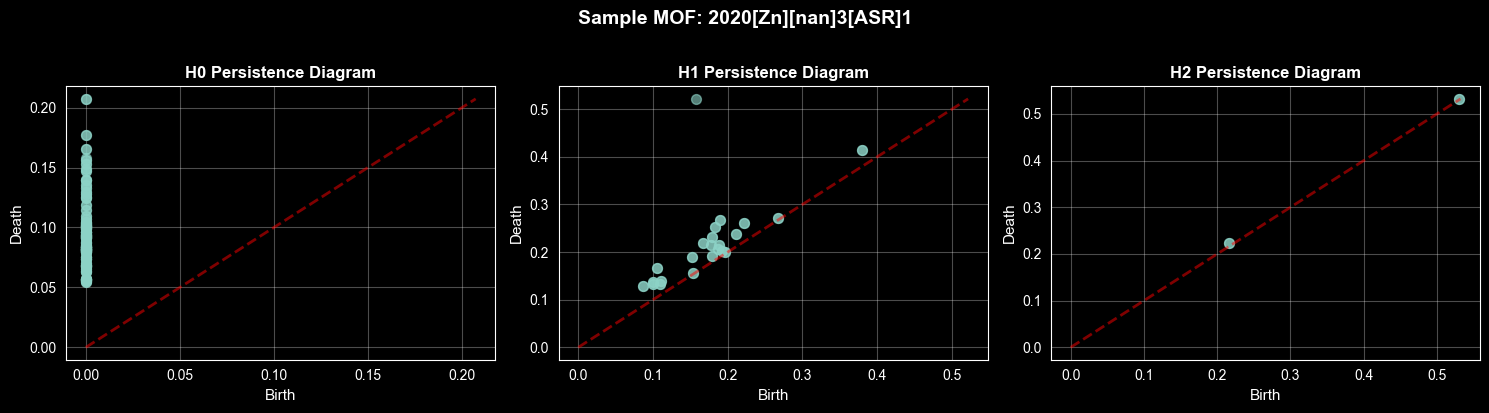

In [10]:
# Visualize sample persistence diagrams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_idx = 0
sample_diagrams = all_diagrams[sample_idx]

for dim in range(3):
    ax = axes[dim]
    dgm = sample_diagrams[dim]
    
    # Remove infinite persistence for visualization
    finite_mask = np.isfinite(dgm[:, 1])
    dgm_finite = dgm[finite_mask]
    
    if len(dgm_finite) > 0:
        ax.scatter(dgm_finite[:, 0], dgm_finite[:, 1], alpha=0.6, s=50)
        
        # Plot diagonal
        max_val = max(dgm_finite[:, 1].max(), dgm_finite[:, 0].max())
        ax.plot([0, max_val], [0, max_val], 'r--', lw=2, alpha=0.5)
        
    ax.set_xlabel('Birth', fontsize=11)
    ax.set_ylabel('Death', fontsize=11)
    ax.set_title(f'H{dim} Persistence Diagram', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Sample MOF: {df.iloc[sample_idx]["material_id"]}', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Top 10 Most Important TDA Features:
         feature  importance
    H1_birth_std    0.046318
    H1_birth_max    0.038028
    H2_death_max    0.026247
 H1_lifetime_max    0.022843
H0_lifetime_mean    0.018416
   H0_death_mean    0.018416
    H2_birth_max    0.017961
    H0_death_max    0.017054
 H0_lifetime_max    0.017054
 H0_lifetime_std    0.015323


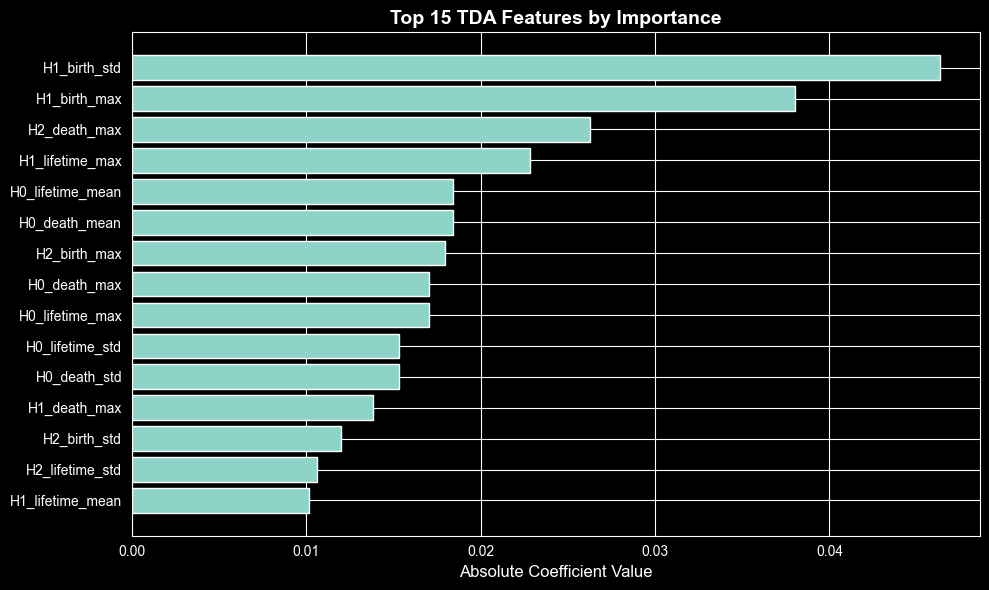

In [11]:
# Feature importance analysis
feature_names = []
for dim in range(3):
    for stat in ['birth_mean', 'birth_std', 'birth_max', 
                 'death_mean', 'death_std', 'death_max',
                 'lifetime_mean', 'lifetime_std', 'lifetime_max']:
        feature_names.append(f'H{dim}_{stat}')

# Get feature coefficients
coefficients = np.abs(model.coef_)
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': coefficients
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important TDA Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot top features
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Absolute Coefficient Value', fontsize=12)
ax.set_title('Top 15 TDA Features by Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## ORBIT5k